In [36]:
import requests
from Bio.PDB import PDBParser, PDBIO, Select
from rdkit import Chem

In [37]:
pdb_id = "7CMD"   # Replace with your PDB ID
url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
response = requests.get(url)
with open(f"{pdb_id}.pdb", "wb") as f:
    f.write(response.content)
print(f"{pdb_id}.pdb downloaded.")

7CMD.pdb downloaded.


In [38]:
parser = PDBParser(QUIET=True)
structure = parser.get_structure(pdb_id, f"{pdb_id}.pdb")

In [39]:
model = structure[0]

print("Chains in the structure:")

for chain in model:
    print(chain.id)

Chains in the structure:
A
B
C
D


In [40]:
chain_to_keep = "A"

for chain in list(model):
    if chain.id != chain_to_keep:
        model.detach_child(chain.id)

io = PDBIO()
io.set_structure(structure)
io.save("7CMD_chainA.pdb")

print("Saved 7CMD_chainA.pdb")

Saved 7CMD_chainA.pdb


In [41]:
structure = parser.get_structure("clean", "7CMD_chainA.pdb")

ligands = set()

for residue in structure.get_residues():
    if residue.id[0].startswith("H_"):
        ligands.add(residue.resname)

print("Ligands found:")
print(sorted(ligands))

Ligands found:
['TTT', 'ZN']


In [42]:
ligand_name = "TTT"

In [43]:
class LigandSelect(Select):
    def accept_residue(self, residue):
        return residue.resname == ligand_name

io = PDBIO()
io.set_structure(structure)
io.save(f"{ligand_name}.pdb", LigandSelect())

print(f"{ligand_name}.pdb saved.")

TTT.pdb saved.


In [44]:
!obabel TTT.pdb -O TTTop.sdf

1 molecule converted


In [93]:
from rdkit import Chem

ligand = Chem.SDMolSupplier("TTTop.sdf", removeHs=False)[0]

print(ligand.GetNumAtoms())

43


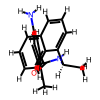

In [95]:
from rdkit.Chem import Draw

Draw.MolToImage(ligand, size=(100,100))

In [96]:
print(Chem.MolToSmiles(ligand))

[H]c1c([H])c(C([H])([H])[H])c(C(=O)N([H])[C@@]([H])(c2c([H])c([H])c([H])c3c([H])c([H])c([H])c([H])c23)C([H])([H])[H])c([H])c1N([H])[H]


In [97]:
ligand = Chem.AddHs(ligand)
print(Chem.MolToSmiles(ligand))

[H]c1c([H])c(C([H])([H])[H])c(C(=O)N([H])[C@@]([H])(c2c([H])c([H])c([H])c3c([H])c([H])c([H])c([H])c23)C([H])([H])[H])c([H])c1N([H])[H]


In [98]:
from openff.toolkit import Molecule

off_mol = Molecule.from_rdkit(
    ligand,
    allow_undefined_stereo=True
)

In [100]:
off_mol.assign_partial_charges("openff-gnn-am1bcc-0.1.0-rc.3.pt")

In [101]:
print(off_mol.partial_charges)

[0.679712597713914 -0.10307487429574479 -0.019579007788452993 -0.1310393470664357 -0.09600084604218949 -0.041231210841689 -0.10703627349332322 -0.15362920941308486 -0.12611765743688094 -0.05644404844835747 0.13560301481291306 -0.11932275028422822 -0.17443468750909316 -0.1291574198146199 -0.5968485433001851 -0.09981835962728013 -0.8200404602427815 -0.567918177260909 0.14891758976980699 -0.11181655110314835 -0.08757834465697754 -0.11631917537644852 -0.12044071735337723 0.13332701145216477 0.13417290566965592 0.14427340446516526 0.13103774605795396 0.04723692356153976 0.04723692356153976 0.04723692356153976 0.1342708361010219 0.13434240637823594 0.13473190783068192 0.13396868525549424 0.3943592351536418 0.3943592351536418 0.3128843349079753 0.08454026697680007 0.046748798773732295 0.046748798773732295 0.046748798773732295 0.13461409925028336 0.13077521740004075] elementary_charge


In [102]:
off_mol.to_file(
    "GRL0617_openff.pdb",
    file_format="pdb"
)

In [103]:
from openmm.app import PDBFile, Modeller

# Load protein and ligand
protein = PDBFile("output_pdbfixer.pdb") #from 01_prepare_protein
ligand = PDBFile("GRL0617_openff.pdb")

# Create modeller with protein
modeller = Modeller(protein.topology, protein.positions)

# Add ligand
modeller.add(ligand.topology, ligand.positions)

# Save merged complex
with open("complex.pdb", "w") as f:
    PDBFile.writeFile(modeller.topology, modeller.positions, f)

print("Saved complex.pdb")

Saved complex.pdb


In [104]:
from openmmforcefields.generators import SMIRNOFFTemplateGenerator

generator = SMIRNOFFTemplateGenerator(
    molecules=off_mol
)

In [ ]:
#suggestiondef parameterize_ligand(sdf_file):
    ...

In [110]:
from openmm.app import *
from openmm import *
from openmm.unit import *

print('Loading...')
pdb = PDBFile('complex.pdb')
forcefield = ForceField('amber19-all.xml', 'amber19/tip3pfb.xml')
forcefield.registerTemplateGenerator(
    generator.generator
)
modeller = Modeller(pdb.topology, pdb.positions)

print('Adding hydrogens...')
modeller.addHydrogens(forcefield, pH=5.0)
print('Adding solvent...')
modeller.addSolvent(forcefield, model='tip3p', padding=1*nanometer, boxShape='cube', ionicStrength=0.15*molar)

print("Saving solvated structure...")

PDBFile.writeFile(
    modeller.topology,
    modeller.positions,
    open("output_solvated.pdb", "w")
)

Loading...
Adding hydrogens...
Adding solvent...
Saving solvated structure...


In [ ]:
##Creating system.xml, which was used on Google Colab to run the simulation#####

In [114]:
from openmm import XmlSerializer

xml = XmlSerializer.serialize(system)

with open("system.xml", "w") as f:
    f.write(xml)

In [ ]:
To read later in Colab

In [ ]:
################GOOGLE COLAB############################